# Remote Sensing: Sampling and Quantization Effects

This notebook demonstrates how spatial sampling and intensity quantization affect image representation, quality, and transmission efficiency for high-resolution satellite images.

## Task 1: Load High-Resolution Color Image

We'll use a sample satellite image.

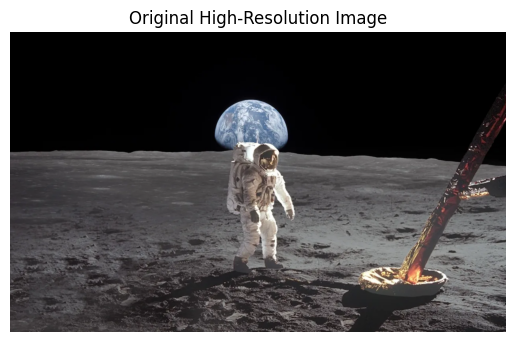

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load high-resolution color image 
img = cv2.imread('moon.webp')
if img is None:
    raise Exception('Image not found!')

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.title('Original High-Resolution Image')
plt.axis('off')
plt.show()

## Task 2: Spatial Sampling (Resolution Reduction)

We will reduce the image resolution stepwise: 512×512 → 256×256 → 128×128.

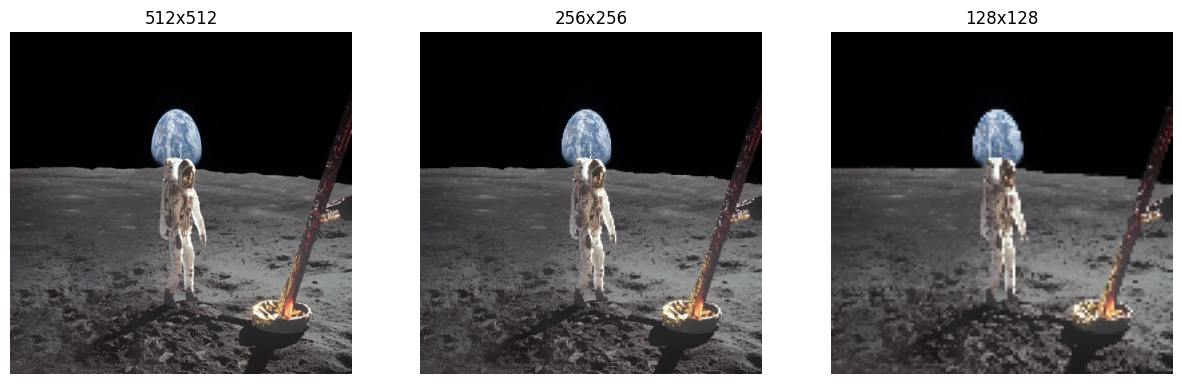

In [2]:
# Resize image to different resolutions
img_512 = cv2.resize(img_rgb, (512, 512))
img_256 = cv2.resize(img_rgb, (256, 256))
img_128 = cv2.resize(img_rgb, (128, 128))

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_512)
plt.title('512x512')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img_256)
plt.title('256x256')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(img_128)
plt.title('128x128')
plt.axis('off')

plt.show()

## Task 3: Intensity Quantization (Gray Level Reduction)

We will reduce the number of gray levels: 256 → 64 → 16.

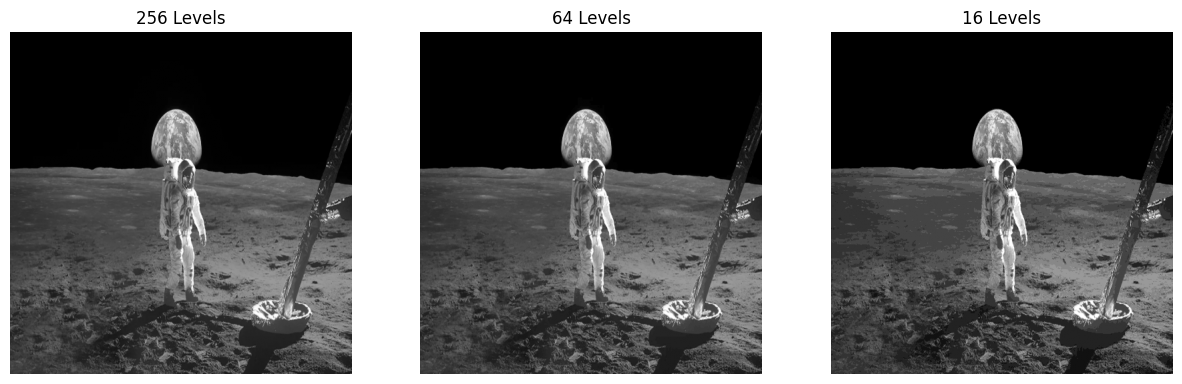

In [3]:
# Convert to grayscale for quantization
gray_512 = cv2.cvtColor(img_512, cv2.COLOR_RGB2GRAY)

# Quantize to 256, 64, and 16 levels
def quantize(img, levels):
    step = 256 // levels
    return (img // step) * step

q_256 = quantize(gray_512, 256)
q_64 = quantize(gray_512, 64)
q_16 = quantize(gray_512, 16)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(q_256, cmap='gray')
plt.title('256 Levels')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(q_64, cmap='gray')
plt.title('64 Levels')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(q_16, cmap='gray')
plt.title('16 Levels')
plt.axis('off')

plt.show()

## Task 4: Visual Quality & Data Efficiency Comparison

Let's compare the images visually and discuss data storage/transmission efficiency.

In [4]:
# Calculate and print image sizes (in bytes)
import sys
sizes = [img_512.nbytes, img_256.nbytes, img_128.nbytes]
quant_sizes = [q_256.nbytes, q_64.nbytes, q_16.nbytes]

print('Resolution Data Sizes (bytes):')
print(f'512x512: {sizes[0]} | 256x256: {sizes[1]} | 128x128: {sizes[2]}')
print('Quantized Data Sizes (bytes):')
print(f'256 levels: {quant_sizes[0]} | 64 levels: {quant_sizes[1]} | 16 levels: {quant_sizes[2]}')

Resolution Data Sizes (bytes):
512x512: 786432 | 256x256: 196608 | 128x128: 49152
Quantized Data Sizes (bytes):
256 levels: 262144 | 64 levels: 262144 | 16 levels: 262144


## Task 5: Questions & Discussion

**Q1: Trade-off between image quality and data size**
- Reducing resolution and quantization levels decreases data size, but also degrades visual quality. Essential details may be lost if levels are too low.

**Q2: Importance of selecting appropriate sampling and quantization levels**
- For applications needing fine detail (e.g., urban mapping, crop analysis), higher resolution and more gray levels are needed.
- For quick transmission or rough monitoring (e.g., weather, IoT sensors), lower levels may suffice.

**Q3: Real-world implications for satellite imaging or IoT camera-based systems**
- Satellite images for scientific analysis require high fidelity, but bandwidth is limited. Adaptive compression (region-based, multi-resolution) is often used.
- IoT cameras may use aggressive quantization/sampling to save power and bandwidth, but must balance with the need for actionable information.

**Summary Table:**
| Setting         | Data Size | Visual Quality | Use Case Example           |
|----------------|-----------|---------------|---------------------------|
| High Resolution, 256 Levels | Large      | Excellent      | Scientific mapping        |
| Low Resolution, 16 Levels   | Small      | Poor           | Quick event detection     |
| Medium, 64 Levels           | Moderate   | Good           | General monitoring        |